# Simple Linear Regression (Gradient Descent) - Improved Version

This notebook improves convergence criteria and training safety based on Assignment1_1.


In [9]:
import matplotlib.pyplot as plt

# Data
x = [1, 2, 4, 6, 8]
y = [2, 5, 6, 9, 11]

# Parameters
a = 0.0
b = 0.0
learning_rate = 0.01
eps_grad = 0.01
eps_loss = 0.01
max_iter = 10000
n = len(x)

# History
mse_history = []
grad_norm_history = []


# Definition of Functions


In [10]:
def mse(a, b):
    acc = 0.0
    for i in range(n):
        residual = (a + b * x[i] - y[i])
        acc += residual * residual
    value = acc / n
    mse_history.append(value)
    return value


def gradients(a, b):
    acc_a = 0.0
    acc_b = 0.0
    for i in range(n):
        residual = (a + b * x[i] - y[i])
        acc_a += 2.0 * residual
        acc_b += 2.0 * residual * x[i]
    grad_a = acc_a / n
    grad_b = acc_b / n
    return grad_a, grad_b


def sqrt_newton(val, iters=20):
    if val <= 0.0:
        return 0.0
    guess = val if val > 1.0 else 1.0
    for _ in range(iters):
        guess = 0.5 * (guess + val / guess)
    return guess


def closed_form_solution(x, y):
    x_mean = sum(x) / len(x)
    y_mean = sum(y) / len(y)

    num = 0.0
    den = 0.0
    for i in range(len(x)):
        dx = x[i] - x_mean
        dy = y[i] - y_mean
        num += dx * dy
        den += dx * dx

    if den == 0.0:
        raise ValueError('Closed-form slope is undefined because all x are identical.')

    b_star = num / den
    a_star = y_mean - b_star * x_mean
    return a_star, b_star


In [11]:
prev = mse(a, b)
iterations = 0

for it in range(1, max_iter + 1):
    grad_a, grad_b = gradients(a, b)
    grad_norm = sqrt_newton(grad_a * grad_a + grad_b * grad_b)
    grad_norm_history.append(grad_norm)

    a -= learning_rate * grad_a
    b -= learning_rate * grad_b

    cur = mse(a, b)
    iterations = it

    if grad_norm < eps_grad:
        break

    prev = cur

# Closed-form reference
a_star, b_star = closed_form_solution(x, y)

print(f'iterations: {iterations}')
print(f'a (GD): {a:.8f}')
print(f'b (GD): {b:.8f}')
print(f'mse (GD): {cur:.10f}')
print(f'grad_norm(final): {grad_norm_history[-1]:.10f}')
print('---')
print(f'a (closed-form): {a_star:.8f}')
print(f'b (closed-form): {b_star:.8f}')
print(f'|a-a*|: {abs(a-a_star):.10f}')
print(f'|b-b*|: {abs(b-b_star):.10f}')


iterations: 806
a (GD): 1.53631105
b (GD): 1.20447730
mse (GD): 0.3744837227
grad_norm(final): 0.0099702928
---
a (closed-form): 1.55487805
b (closed-form): 1.20121951
|a-a*|: 0.0185670036
|b-b*|: 0.0032577860


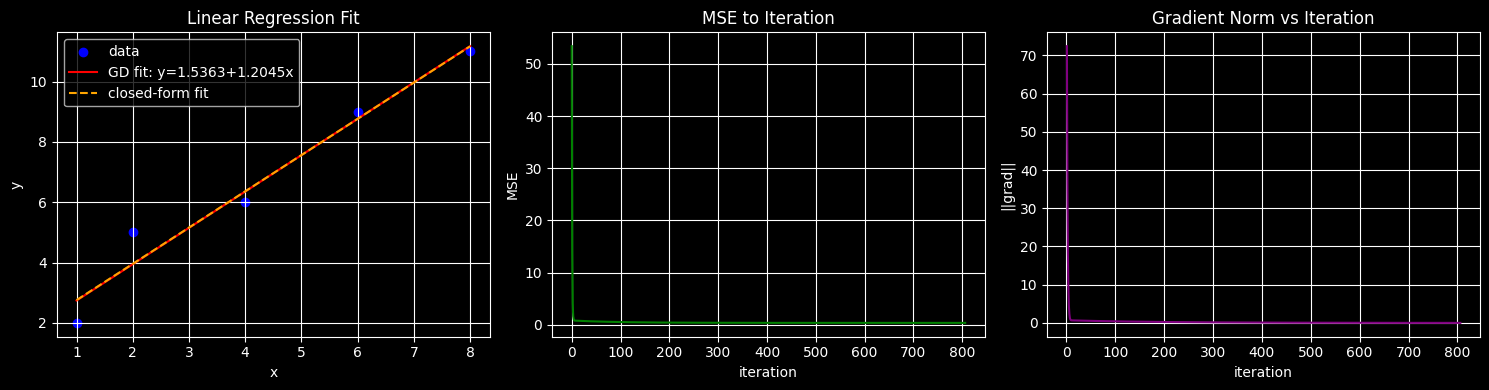

In [16]:
# 3. Visualization
plt.figure(figsize=(15, 4))

# Subplot 1: data + fitted line
plt.subplot(1, 3, 1)
plt.scatter(x, y, label='data', color='blue')
y_fit_gd = [a + b * xi for xi in x]
y_fit_closed = [a_star + b_star * xi for xi in x]
plt.plot(x, y_fit_gd, label=f'GD fit: y={a:.4f}+{b:.4f}x', color='red')
plt.plot(x, y_fit_closed, label='closed-form fit', color='orange', linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True)

# Subplot 2: MSE over iterations
plt.subplot(1, 3, 2)
plt.plot(range(len(mse_history)), mse_history, color='green')
plt.xlabel('iteration')
plt.ylabel('MSE')
plt.title('MSE to Iteration')
plt.grid(True)

# Subplot 3: Gradient norm over iterations
plt.subplot(1, 3, 3)
plt.plot(range(1, len(grad_norm_history) + 1), grad_norm_history, color='purple')
plt.xlabel('iteration')
plt.ylabel('||grad||')
plt.title('Gradient Norm to Iteration')
plt.grid(True)

plt.tight_layout()
plt.show()
